In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import os
os.makedirs('plots', exist_ok=True)

sns.set_style("whitegrid")

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))

print("Shape:", df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## Data Cleaning & Profiling

Checking for missing values, duplicate rows, and class distribution before proceeding to modeling.


In [4]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check class balance
print("\nClass distribution:\n", df['species_name'].value_counts())

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Duplicate rows: 1

Class distribution:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Remove duplicate row
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicate:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after removing duplicate: (149, 6)
Duplicate rows remaining: 0


## Feature Exploration

Visualizing feature distributions and pairwise relationships to understand how the three species differ.

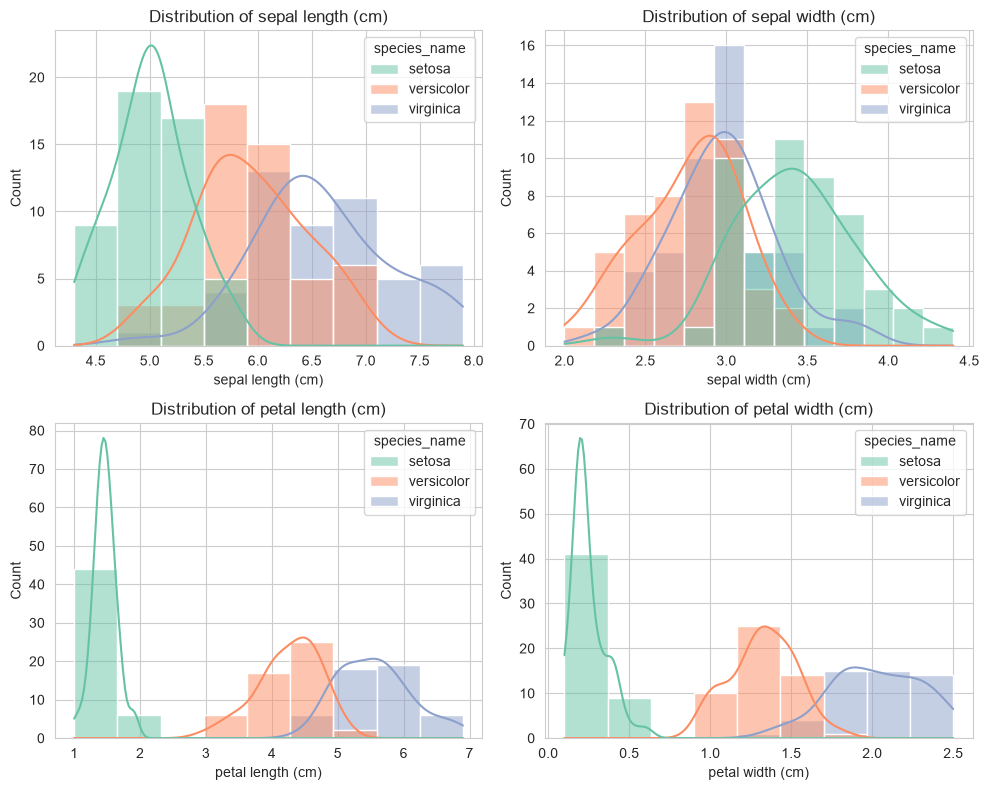

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, col in zip(axes.flatten(), iris.feature_names):
    sns.histplot(data=df, x=col, hue='species_name', kde=True, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=300)
plt.show()

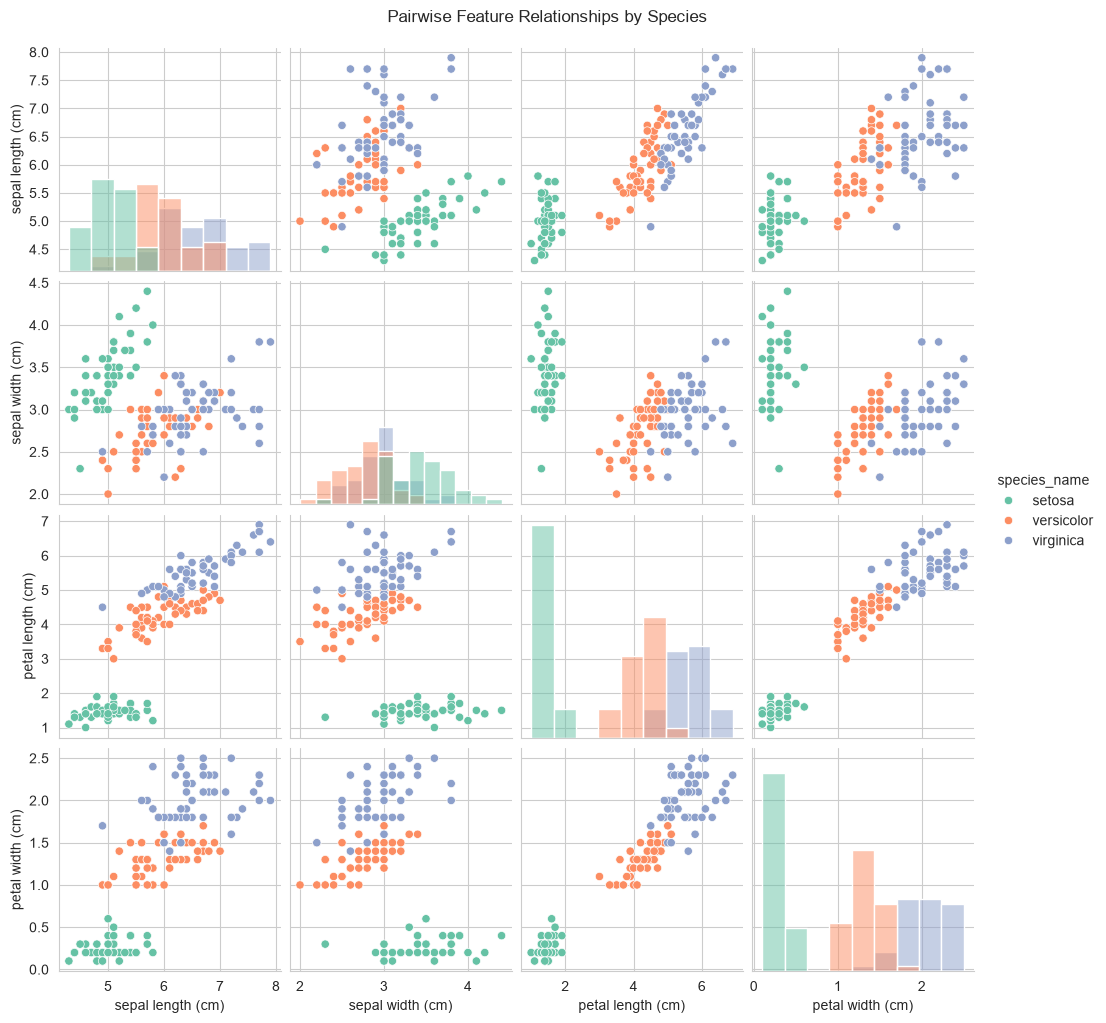

In [8]:
pair_grid = sns.pairplot(df, vars=iris.feature_names, hue='species_name', palette='Set2', diag_kind='hist')
pair_grid.fig.suptitle('Pairwise Feature Relationships by Species', y=1.02)
pair_grid.savefig('plots/pairplot.png', dpi=300)
plt.show()

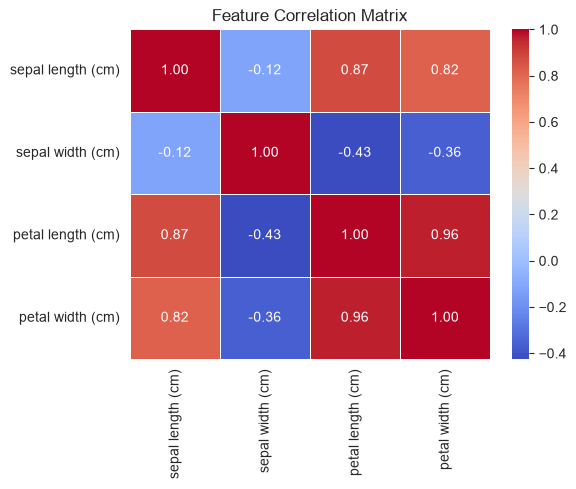

In [9]:
plt.figure(figsize=(6,5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)
plt.show()

## Train/Test Split

Splitting data into 80% training and 20% testing, with stratification to preserve class balance and avoid data leakage.

In [10]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Feature scaling (fit on train only, to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Training set size: (119, 4)
Test set size: (30, 4)
Scaling done.


## Model Training

Training and comparing three classifiers: Logistic Regression, Decision Tree, and Random Forest.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    trained_models[name] = model
    predictions[name] = y_pred
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


## Model Evaluation

In [12]:
results = []
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.933333,0.933333,0.933333,0.933333


In [13]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}\n")

print("Classification Report:\n")
print(classification_report(y_test, predictions[best_model_name], target_names=iris.target_names))

Best performing model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Confusion Matrix Heatmaps (All Models)

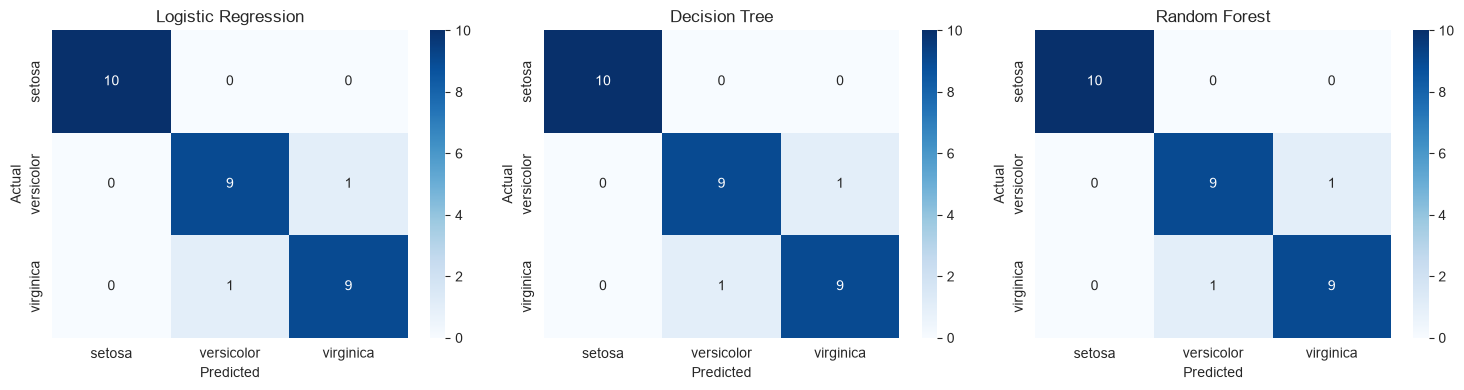

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=300)
plt.show()

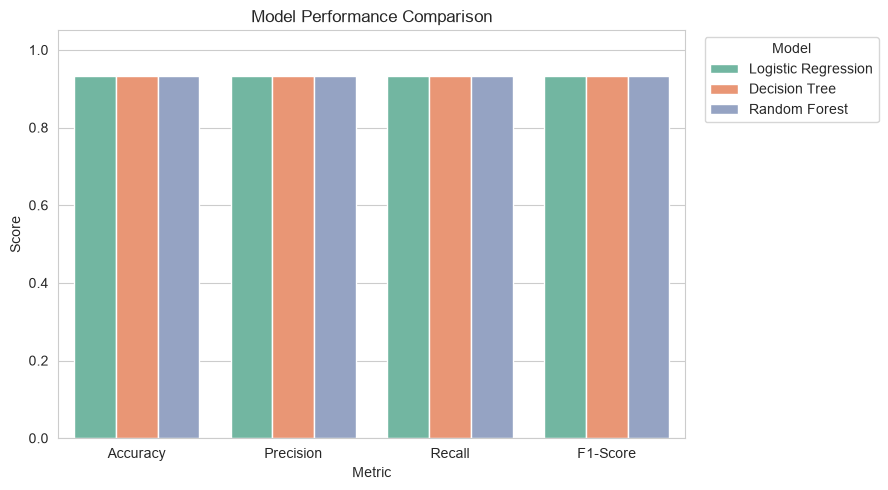

In [15]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9,5))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=300)
plt.show()

## Decision Boundary Visualization

Visualizing the decision boundary using the two most discriminative features (petal length and petal width) with a Random Forest classifier.

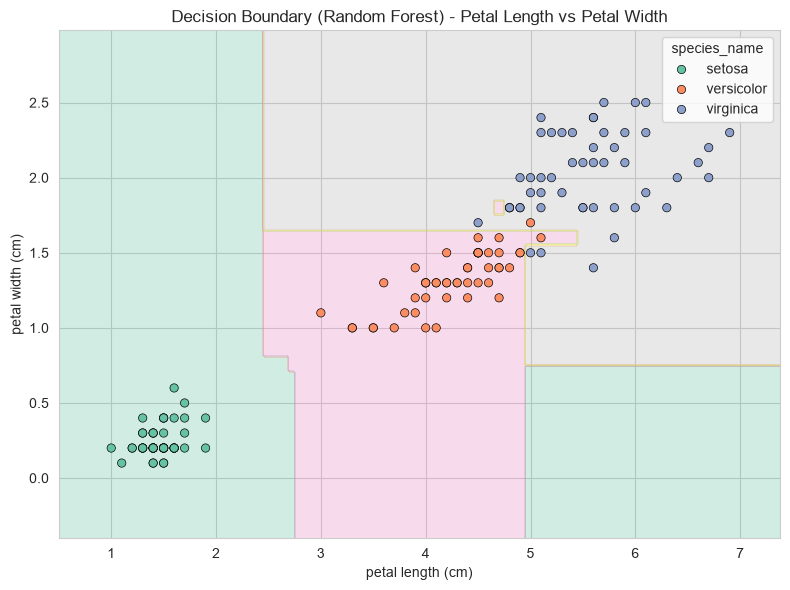

In [16]:
feat_x, feat_y = 'petal length (cm)', 'petal width (cm)'
X_2d = df[[feat_x, feat_y]].values
y_2d = df['species'].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

clf_2d = RandomForestClassifier(n_estimators=100, random_state=42)
clf_2d.fit(X_2d_train, y_2d_train)

# Create mesh grid
x_min, x_max = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
y_min, y_max = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['species_name'], palette='Set2', edgecolor='black')
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title('Decision Boundary (Random Forest) - Petal Length vs Petal Width')
plt.tight_layout()
plt.savefig('plots/decision_boundary.png', dpi=300)
plt.show()

## Insights & Conclusion

- All three models (Logistic Regression, Decision Tree, Random Forest) achieved the same accuracy (93.3%) on this dataset, since the Iris classes are largely separable with clean, well-behaved features.
- Petal length and petal width are the most discriminative features for separating the three species, as seen clearly in the pair plot and the decision boundary visualization.
- Setosa is almost always perfectly classified (100% precision, recall, and f1-score), while most misclassifications occur between versicolor and virginica, which have some feature overlap.
- Feature scaling was applied using StandardScaler, fit only on the training set, to avoid data leakage into the test set.
- Stratified train/test splitting ensured that class proportions remained balanced across both sets.
- One duplicate row was identified and removed during data cleaning; no missing values were found.

This notebook demonstrates a complete, leakage-free ML classification pipeline: data profiling, exploratory visualization, train/test splitting, multi-model training, and thorough evaluation using accuracy, precision, recall, F1-score, confusion matrices, and decision boundary plots.